# Clasificación de Texto con BERT y Hugging Face — **versión comentada**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller_3/0-text-classification-with-hf-comentado.ipynb)

> **📘 Sobre este notebook:** esta es la **versión comentada por el Grupo Delta** del notebook guía `1-text-classification-with-hf.ipynb` de la sesión 3 del curso. El código es **exactamente el mismo** del original (por eso conservamos sus salidas); lo que hicimos fue añadir explicaciones pensadas para quien está empezando a programar: comentarios línea a línea, glosarios y secciones "🎯 Objetivo" antes de cada bloque.

En este notebook implementaremos un clasificador de noticias en español utilizando transformers pero ya basandonos en un modelo pre-entrenado tipo Bidirectional Encoder Representation from Transformers o BERT por sus siglas y disponible en Hugging Face Hub. El propósito de esta tarea es aprender a utilizar modelos pre-entrenados que por si mismos, sería sumamente costoso entrenar desde cero, tanto por el poder de computo como la disponibilidad de datos de entrenamiento. Entonces gran parte de la labor ya ha sido realizada por nosotros. Nuestra tarea ahora es especializar el modelo en la tarea que tenemos a la mano.

En esta ocasión, vamos a apartarnos de Pytorch Lightning y harémos uso extensivo de la herramientas de Hugging Face, las cuales están especialmente desarrolladas para este tipo de tareas, incluyendo la interacción con modelos pre-entrenados.

#### 🧭 Antes de empezar: el mapa del notebook

1. **Cargar el dataset** de noticias en español desde Hugging Face Hub.
2. **EDA**: explorar balance de clases y longitud de los textos.
3. **Tokenizador**: cargar el MISMO tokenizador con el que se entrenó BERT en español (BETO).
4. **Modelo 1 — BERT congelado + capa lineal**: solo entrenamos la cabeza clasificadora.
5. **Modelo 2 — BERT congelado + clasificador propio**: una red MLP definida por nosotros.
6. **Modelo 3 — Fine-tuning completo**: se entrenan TODAS las capas del modelo.
7. **Conclusiones**: cuándo conviene cada enfoque.

#### 🔑 Mini-glosario para principiantes

| Término | Significado en palabras simples |
|---|---|
| **Hugging Face (HF)** | Una empresa/community que publica un "Hub" (como un GitHub de modelos y datasets de NLP) y librerías de Python para usarlos. |
| **Checkpoint** | Un modelo ya entrenado, guardado y publicado en el Hub. Descargarlo es gratis: `from_pretrained("nombre")`. |
| **Token** | Pedazo de texto (una palabra o parte de palabra). Los modelos no leen letras: leen números que representan tokens. |
| **Tokenizador** | El programa que convierte texto en tokens y les asigna un número (id) del vocabulario. |
| **Embedding** | Vector de números que representa el "significado" de un token. Palabras parecidas tienen vectores parecidos. |
| **Featurizer / congelar** | Usar el modelo pre-entrenado solo para "extraer características" (embeddings), sin re-entrenarlo. Se logra poniendo `requires_grad = False`. |
| **Fine-tuning** | Re-entrenar el modelo completo (todas sus capas) sobre nuestros datos, partiendo de los pesos pre-entrenados. |
| **Época (epoch)** | Una pasada completa por todos los datos de entrenamiento. |
| **Batch** | Grupo pequeño de ejemplos que el modelo procesa a la vez antes de actualizar sus pesos. |

#### Referencias
- Dataset: https://huggingface.co/datasets/mteb/spanish_news
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [1]:
# --- Setup inicial: detectar dónde estamos ejecutando el notebook ---

# 'warnings' es un módulo de Python que emite avisos (no errores) cuando algo
# puede estar mal (por ejemplo, funciones que quedarán obsoletas). Aquí le
# decimos que los OCULTE, para que la salida del notebook se vea limpia.
import warnings

warnings.filterwarnings('ignore')

# --- ¿Estamos en Google Colab o en nuestra máquina? ---
# 'try/except' intenta ejecutar un código y, si falla con el error indicado,
# ejecuta el bloque 'except' en lugar de detener el programa.
try:
    # Este import SOLO existe dentro de Google Colab. Si estamos en Colab,
    # funciona y por lo tanto IN_COLAB queda en True.
    import google.colab
    IN_COLAB = True
except ImportError:
    # Si el import falla (ImportError), es que no estamos en Colab:
    # estamos en un entorno local (por ejemplo VS Code).
    IN_COLAB = False

# Esta variable la usaremos más abajo para decidir tamaños de batch,
# instalación de librerías, etc. Colab tiene GPU; nuestra máquina quizá no.
print('¿Ejecutando en Google Colab?', IN_COLAB)

In [ ]:
# --- Instalamos las librerías que hacen falta ---

# La línea empieza con '!' porque NO es código Python: es un comando de
# terminal (shell). Dentro de un notebook, '!' permite ejecutar comandos del
# sistema directamente desde una celda.

# 'test ... && ...' es un truco del shell: el comando que va después de '&&'
# solo se ejecuta si lo anterior fue verdadero. Es decir: SOLO instalamos
# paquetes si realmente estamos en Colab (en local se asume que ya los
# instalamos una vez con 'pip install' y no hay que repetirlo cada corrida).
!test '{IN_COLAB}' = 'True' && pip install torchinfo evaluate

# ¿Qué instalamos?
# - torchinfo  -> librería pequeña que imprime un resumen bonito del modelo
#                (capas, tamaños, cuántos parámetros tiene). Como un
#                model.summary() de Keras pero para PyTorch.
# - evaluate   -> librería de Hugging Face con métricas listas para usar
#                (accuracy, F1, etc.) sin escribir la fórmula nosotros.

### Cargando el dataset

**🎯 Objetivo de la sección:** traernos el dataset de noticias en español desde el Hugging Face Hub a la memoria, y convertirlo en un DataFrame de pandas para poder inspeccionarlo fácilmente.

Este es un dataset pequeño de articulos de noticias en idioma español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

> **💡 Para principiantes:** el "Hugging Face Hub" es como un GitHub de datos y modelos. `load_dataset('mteb/spanish_news')` descarga el dataset a un caché local la primera vez; en las siguientes corridas lo lee del caché (es rápido).

In [3]:
# 'datasets' es la librería de Hugging Face para manejar datasets.
# load_dataset descarga/carga el dataset por su nombre en el Hub.
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")

# Cargamos SOLO el split de entrenamiento (split='train'). Un "split" es una
# partición del dataset: train (para entrenar), validation/test (para evaluar).
dataset = load_dataset('mteb/spanish_news', split='train')

# set_format(type="pandas") le dice al dataset: "cuando te pida datos,
# devuélvemelos como tabla de pandas". Es cómodo para explorar (EDA).
dataset.set_format(type="pandas")

# to_pandas() convierte TODO el dataset a un DataFrame (una tabla con filas
# y columnas, como un Excel) para poder verlo y manipularlo.
df = dataset.to_pandas()

# head() muestra las primeras 5 filas: siempre es lo primero que hay que
# hacer con datos nuevos, para ver qué pinta tienen.
df.head()

,language,label,newspaper,hash,text
0,es,0,xataka,e5f5f105181fa53533884c67c5d1bc2e76a6cbde,Una de las novedades que Google introdujo en s...
1,es,9,bbc_news,48c2c042c74264da3c623bad78b5e9ca75531207,"Fuente de la imagen, AFPUn boceto de la cápsul..."
2,es,5,car_and_driver,783d78e160f58b97982bb1eec0bb5b1d9ae55f21,Car and Driver participa en varios programas d...
3,es,2,diario_as,a43e5616a804b8dfe91197634030bbb06f2c8474,“Podría haber vuelto para terminar mi carrera ...
4,es,3,el_periodico,0415b33242c0941fa9d005de7ff5bfa8536fae11,La Generalitat y el Gobierno llevan años jugan...


In [4]:
import numpy as np

# --- Construcción del mapa texto de categoría -> número (id) ---
# Los modelos de ML no entienden categorías en texto ("política", "deportes"...),
# entienden números. Hay que crear el mapeo categoría <-> id.

# np.unique(df['label']) -> lista de categorías SIN repetir, ordenadas.
# enumerate(...) -> recorre la lista dándole a cada elemento un número:
#                   (0, 'ciencia'), (1, 'deportes'), ...
# dict(...) -> convierte esos pares en un diccionario {0: 'ciencia', ...}
id2label = dict(enumerate(np.unique(df['label'])))

# Aquí construimos el diccionario INVERSO: {v: k for k, v in id2label.items()}
# es una "dict comprehension" (como un for en una línea) que recorre cada
# par clave-valor de id2label y crea el par invertido.
label2id = {v: k for k, v in id2label.items()}

# apply(lambda x: ...) aplica una función pequeña a cada fila de la columna.
# En este caso: a cada texto de categoría, le buscamos su número con label2id.
# Con esto creamos la columna 'label_id' (la etiqueta NUMÉRICA que usará el modelo).
df['label_id'] = df['label'].apply(lambda x: label2id[x])

# Reordenamos columnas con df[[...]], y:
# - sample(frac=1) -> devuelve una MUESTRA del 100% de las filas, es decir,
#   las baraja (shuffle) en orden aleatorio. Mezclar los datos es importante
#   para que el modelo no aprenda patrones del orden de llegada.
# - reset_index(drop=True) -> tras barajar, renumera las filas 0, 1, 2, ...
#   y descarta el índice viejo (drop=True: no lo guarda como columna extra).
df = df[['text', 'label', 'label_id']].sample(frac=1).reset_index(drop=True)
df.head()

,text,label,label_id
0,Las cosas no van como el año pasado en Sacrame...,2,2
1,Pocas ciudades rinden tanto tributo a las hamb...,6,6
2,Galicia afrontaba este domingo la jornada elec...,3,3
3,Searchlight acaba de lanzar el primer tráiler ...,1,1
4,El Albacete quiere lograr esta tarde en el Bel...,2,2


En esta ocasión, vamos a explorar un poco más las características del dataset a manera ilustrativa.

**🎯 Objetivo de la sección (EDA):** conocer nuestros datos ANTES de entrenar. Dos preguntas clave:
1. ¿Cuántos ejemplos hay de cada clase? (si una clase tuviera muy pocos ejemplos, el modelo aprendería mal esa clase)
2. ¿Qué tan largos son los textos? (para decidir la longitud máxima de secuencia que usará el modelo)

Primero, observemos la distribución de las clases:

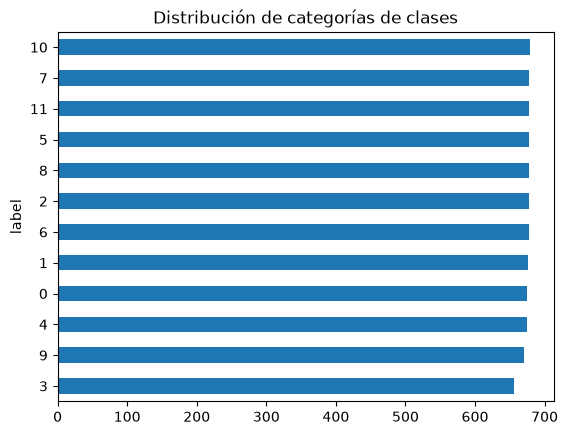

In [5]:
import matplotlib.pyplot as plt

# value_counts() cuenta cuántas filas hay de cada categoría.
# ascending=True ordena de menor a mayor, y plot.barh() dibuja barras
# HORIZONTALES (más legibles cuando los nombres de clase son largos).
df.label.value_counts(ascending=True).plot.barh()
plt.title('Distribución de categorías de clases')
# show() dibuja el gráfico. En notebooks a veces no es imprescindible,
# pero es buena práctica para que el gráfico no se "pegue" a otras salidas.
plt.show()

In [6]:
# Los mismos conteos de antes, pero en números crudos (sin gráfico).
# Ver ambas cosas (gráfico + números) es útil: el gráfico da la intuición
# y los números dan la precisión exacta.
df.label.value_counts()

label
10    679
2     678
8     678
5     678
11    678
7     678
6     677
1     676
4     675
0     675
9     671
3     656
Name: count, dtype: int64

Observamos que es un dataset balanceado.

> **💡 Para principiantes:** "balanceado" = hay casi la misma cantidad de ejemplos por clase. Esto es una BUENA noticia: el accuracy (porcentaje de aciertos) será una métrica confiable. Si estuviera desbalanceado, un modelo tonto que siempre dijera la clase mayoritaria tendría un accuracy alto sin haber aprendido nada.

Ahora observemos la dispersión de las palabras por cada categoría.

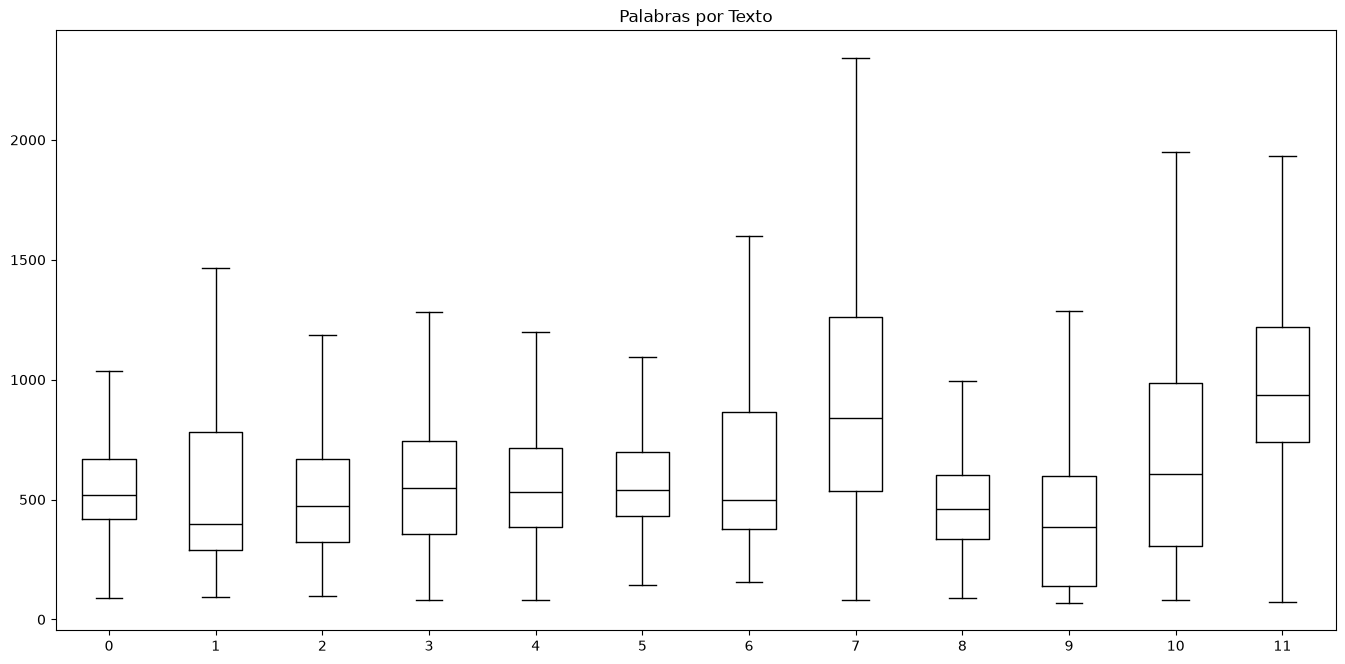

In [7]:
# --- ¿Qué tan largos son los textos de cada categoría? ---

# Paso 1: calcular la longitud de cada texto.
# - df['text'].str.split() -> divide cada texto en una LISTA de palabras
#   (separa por espacios). Ej: "hola mundo" -> ['hola', 'mundo']
# - .apply(len) -> a cada lista le calcula su longitud (número de palabras).
# - Todo eso queda guardado en una NUEVA columna del DataFrame.
df['Palabras por Texto'] = df['text'].str.split().apply(len)

# Paso 2: dibujar un boxplot (diagrama de cajas) por categoría.
# Un boxplot resume la distribución: la caja = donde está el 50% central
# de los datos (entre percentiles 25 y 75), la línea del medio = mediana,
# y los "bigotes" = valores extremos.
# - by='label' -> un box por cada categoría
# - showfliers=False -> NO dibujar los puntos atípicos (outliers) para que
#   el gráfico no se estire por culpa de textos gigantes.
df.boxplot('Palabras por Texto', by='label', grid=False, showfliers=False, color='black', figsize=(16, 8))
plt.suptitle('')   # boxplot añade un título automático feo; lo quitamos
plt.xlabel('')     # el eje X ya se explica solo con los nombres de categorías
plt.show()

Aquí observamos mayor diversidad. Observamos que algunas clases tienden a tener más palabras que otras, e incluso algunas tienen outliers en cuanto a la longitud de los textos. Sin embargo, como nuestra tarea es de clasificación según el texto y durante el entrenamiento vamos a manejar cadenas de tamaño fijo, lo que nos debería importar más que todo es la media/mediana entre todas las categorías.

In [8]:
# groupby('label') agrupa las filas por categoría y luego, para cada grupo,
# calcula la MEDIANA de 'Palabras por Texto'. La mediana es el valor "del
# medio": la mitad de los textos es más corta y la otra mitad más larga.
# La usamos en vez de la media porque es más robusta: un solo texto
# gigantesco no la distorsiona (a la media sí).
df.groupby('label')['Palabras por Texto'].median()

label
0     519.0
1     397.5
2     473.0
3     547.0
4     530.0
5     538.5
6     499.0
7     840.5
8     459.5
9     385.0
10    605.0
11    935.5
Name: Palabras por Texto, dtype: float64

Como podemos observar, la mediana, que como media de tendencia central, tiende a ser más robusta que la media, nos indica que la longitud mediana de los textos entre todas las categorías tiende a rondar por las $\approx500$ palabras. Entonces utilizaremos una longitud de texto acorde durante nuestro entrenamiento.

> **💡 Nota:** este número (≈500 palabras ≈ 512 tokens) no es casual: es justamente el máximo que BERT acepta (`model_max_length`). Por eso más abajo tokenizaremos con `max_length=512`.

In [9]:
# Antes hicimos dataset.set_format(type="pandas"), lo cual hace que al
# pedir ejemplos al dataset, estos lleguen como DataFrames de pandas. Para
# los siguientes pasos (tokenizar con .map, entrenar) necesitamos el
# formato normal de nuevo (diccionarios de Python), así que lo RESTAURAMOS.
dataset.reset_format()

### Definiendo el Tokenizer

**🎯 Objetivo de la sección:** cargar el tokenizador correcto y entender por qué **tiene que ser exactamente el mismo** con el que se entrenó el modelo.

Como la idea en este notebook es la de re-utilizar modelos pre-entrenados, algo a tener en cuenta es que para que esto funcione correctamente, debemos **siempre** utilizar el mismo tokenizador que se usó para entrenar el modelo. Recordemos que el tokenizador asigna un código a cada token del vocabulario, y durante la creación de los embeddings, el modelo asume esto como entrada, por lo que su usamos otro tokenizador, el modelo va a ser incapaz de derivar las relaciones semánticas apropiadas.

> **💡 Analogía para principiantes:** imagina un diccionario español->números donde "casa" = 50. El modelo aprendió que el número 50 significa "casa". Si mañana usas OTRO diccionario donde 50 significa "coche", el modelo seguirá leyendo 50 y pensando "casa". Todo se rompe. Por eso el tokenizador y el modelo siempre van emparejados: `from_pretrained(mismo_id)`.

Para esta tarea, haremos uso de un modelo BERT pre-entrenado en corpus del idioma español. El modelo puede ser encontrado [aquí](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased), es un modelo entrenado por el [Departamento de Ciencias de la Computación de la Universidad de Chile](https://www.dcc.uchile.cl), el cual según los autores, fue entrenado en un gran corpus de idioma español por lo que resulta un buen candidato para la tarea en cuestión.

> **💡 ¿Qué es BETO?** Es el "BERT en español": la misma arquitectura BERT, pero entrenada con textos en español (los BERT originales de Google fueron entrenados en inglés y Wikipedia). El sufijo "wwm-cased" significa *Whole Word Masking* (una estrategia de pre-entrenamiento que enmascara palabras completas, no solo tokens sueltos) y *cased* (respeta MAYÚSCULAS y minúsculas: "Hola" ≠ "hola").

In [10]:
from transformers import AutoTokenizer

# El "id" del checkpoint en el Hub: organización/nombre-del-modelo.
# Con este mismo id cargaremos luego el modelo.
model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"

# AutoTokenizer es una clase " inteligente": lee la configuración del
# checkpoint y te devuelve el tokenizador CORRECTO para ese modelo
# (en este caso, un WordPieceTokenizer de BERT), sin que tengas que
# saber a mano qué clase exacta usar.
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

Ahora sometamos a prueba el tokenizador con la misma frase del notebook anterior.

**🎯 Objetivo:** ver con nuestros propios ojos qué hace un tokenizador: cómo corta el texto y cómo rellena (`padding`) las secuencias hasta una longitud fija.

In [11]:
# Un tokenizador BERT trae tokens especiales. Aquí nos aseguramos de que
# el token de relleno sea '[PAD]'. El padding son celdas "vacías" que se
# agregan al final para que TODOS los textos midan lo mismo (los modelos
# trabajan con tensores rectangulares: no pueden tener filas de distinto largo).
tokenizer.pad_token = '[PAD]'

# tokenizer(...) tokeniza el texto. Los parámetros significan:
# - max_length=10     -> la secuencia final medirá exactamente 10 tokens
# - truncation=True   -> si el texto es más largo que 10, se CORTA
# - padding='max_length' -> si es más corto, se RELLENA con [PAD]
# .tokens() -> nos muestra los tokens en TEXTO (no sus ids), para leerlos.
tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()

['[CLS]',
 'hola',
 'mundo',
 '!',
 '!',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Algo interesante, este tokenizador, por lo menos para las palabras de esta frase de prueba, no separa en tokens distintos estas palabras, esto es justamente la razón por la cual no deberíamos usar un tokenizador diferente con un modelo pre-entrenado, habríamos obtenido tokens diferentes y el modelo no lograría interpretar la semantica como se espera.

> **💡 Para principiantes:** "no separa en tokens distintos" significa que "hola" y "mundo!!" aparecen ENTEROS en el vocabulario del tokenizador. Los tokenizadores tipo BERT usan *subpalabras*: si una palabra no está en el vocabulario, la parten en pedazos conocidos (ej: "corriendo" -> "corr" + "##iendo"). El sufijo ## significa "este trozo va pegado al anterior".

Ahora, observemos su vocabulario.

In [12]:
# vocab_size: cuántos tokens distintos conoce el tokenizador
# (el tamaño de su "diccionario" texto -> número).
tokenizer.vocab_size

31002

Tenemos $31002$ tokens, es una cantidad inferior que el modelo manual que intentamos en la lección anterior, pero lo suficientemente amplio para una tarea de NLP.

Ahora, observemos otros parámetros del tokenizador.

In [13]:
# model_max_length: la longitud MÁXIMA de secuencia que el modelo acepta.
# BERT (y BETO) fueron diseñados con 512 posiciones de "positional encoding",
# por eso no pueden procesar secuencias más largas (habría que trocear el texto).
tokenizer.model_max_length

512

In [14]:
# model_input_names: los nombres de las entradas que el modelo espera.
# Nos dice: "cuando me llames, pásame estas claves".
# Para BERT son 'input_ids' y 'token_type_ids' y 'attention_mask'.
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

Primero, observamos que el tokenizador por defecto maneja un tamaño de secuencia de $512$, convenientemente al rededor de la misma longitud mediana de nuestro dataset, por lo que resulta perfecto para nuestro caso de uso. Finalmente, observamos sus salidas, las cuales serán las entradas a nuestro modelo. Como ya debemos saber, `input_ids` son los indices de los tokens y `attention_mask` es la máscara de atención cuando tenemos tokens irrelevantes (como el padding) en la cadena.

> **💡 Las dos entradas del modelo, en cristiano:**
> - **`input_ids`**: la lista de números de cada token. Ej: `[4, 1024, 987, 5, 0, 0]` (0 = [PAD]).
> - **`attention_mask`**: una lista paralela de 1s y 0s. 1 = "este token es real, pásale atención"; 0 = "esto es relleno, IGNÓRALO". Es la forma de decirle al modelo qué celdas del rectángulo de padding no cuentan.

## Usando un modelo BERT pre-entrenado sencillo

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/bert-architecture.png?raw=1)
![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/bert-tokenization.png?raw=1)

Primero, vamos a probar con un modelo pre-entrenado sin mayor modificación a la capa de clasificación. Hugging Face ofrece una clase utilitaria para inicializar el modelo en modo de clasificación de secuencias, lo cual hará que convenientemente tengamos una capa o cabeza de clasificación en el modelo, justo con la cantidad de clases que definamos.

Recordemos que el modelo y el tokenizador deben pertenecer al mismo "paquete", por lo que invocamos a `from_pretrained` con el mismo id que al tokenizer.

Técnicamente hay dos formas de utilizar un modelo pre-entrenado:

1. Como Featurizer: Es decir, vamos a utilizar todas las capas de codificación del modelo **sin re-entrenarlas** o lo que sería lo mismo **congelandolas** haciendo que lo único que vayamos a entrenar sea el clasificador en si.
2. Fine Tuning: Es decir, dejar todas las capas entrenables y entrenar el modelo en su totalidad, a partir del checkpoint del modelo pre-entrenado, para nuestra tarea especifica.

### BERT pre-entrenado como featurizer (simple)

Una ventaja de este enfoque es que es menos costoso de entrenar, a nivel de recursos de computo, ya que no vamos a calcular gradientes para todas las capas sino para la capa de clasificación. Incluso, no es necesario que utilicemos deep learning para la clasificación final, podemos usar algoritmos clasicos, que parten de los embeddings producidos por el modelo pre-entrenado.

Otra ventaja es que debido a que puede ser mucho más rápido de entrenar que no solo un modelo desde cero, sino más rápido que fine tuning, nuevamente, porque ya no es necesario calcular gradientes para todo el modelo, sino solo para la capa de clasificación de nuestro interes.

> **🧠 Recuerda del curso:** el *gradiente* es el número que le dice a cada peso del modelo en qué dirección y cuánto moverse para reducir el error. Calcular gradientes para los ~110 millones de parámetros de BERT es caro; calcularlos solo para una capa final de ~9 mil parámetros es baratísimo. Esa es toda la magia de congelar el modelo.

In [15]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

# --- ¿Hay GPU disponible? ---
# torch.cuda.is_available() -> True si hay tarjeta gráfica NVIDIA usable.
# device guarda "cuda" (GPU) o "cpu". Entrenar en GPU es decenas de veces
# más rápido: SIEMPRE conviene usarla si existe (en Colab: Entorno de
# ejecución -> Cambiar tipo de entorno -> GPU T4).
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tokenizamos una frase de prueba, esta vez con return_tensors='pt' para que
# devuelva TENSORES de PyTorch ('pt' = PyTorch) en vez de listas de Python.
inputs = tokenizer("hola mundo!!!", max_length=10, truncation=True, padding='max_length', return_tensors='pt')

print(f"Input Shapes & Types:")
# Un tensor tiene .shape (dimensiones) y .dtype (tipo de dato).
# Con un dict comprehension recorremos input_ids/attention_mask y mostramos
# forma y tipo de cada uno.
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

# --- Cargamos el modelo en "modo clasificación de secuencias" ---
# AutoModelForSequenceClassification toma el BERT pre-entrenado y le PEGA
# ENCIMA una cabezita de clasificación nueva (una capa lineal) con la
# cantidad de salidas que pidamos:
# - num_labels=len(label2id) -> una salida por cada clase (12 categorías).
# - .to(device) -> mueve el modelo a la GPU (los datos también deben ir ahí;
#   si no, error de "tensors on different devices").
# La primera vez descarga ~420 MB del modelo pre-entrenado.
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(label2id)).to(device)

# --- CONGELAMOS el modelo base para usarlo solo como featurizer ---
# model.base_model es el BERT en sí (las 12 capas del encoder).
# parameters() recorre TODOS sus pesos entrenables.
# requires_grad = False le dice a PyTorch: "no calcules gradientes para
# estos pesos, no los muevas". Solo quedará entrenable la capa final.
for param in model.base_model.parameters():
    param.requires_grad = False

# --- Resumen del modelo con torchinfo ---
# Pasamos las FORMAS y TIPOS de las 3 entradas del modelo (input_ids,
# token_type_ids, attention_mask), repetidas 3 veces (una por entrada).
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
# torch.no_grad() le dice a PyTorch: "no guardes gradientes mientras hago
# esto" -> ahorra memoria y tiempo (no vamos a entrenar en este momento).
# col_names elige qué columnas mostrar en la tabla resumen:
# input_size, output_size, num_params (cuántos pesos) y trainable
# (si son entrenables). Lo importante: ver que la mayoría dice "N/A"
# en trainable -> solo la última capa se entrena.
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Input Shapes & Types:
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 29507.82it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Observamos que el modelo tiene una capa `BertModel` que corresponde al modelo pre-entrenado y finaliza con una capa lineal que sería nuestro clasificador, esta es una capa proporcionada para nosotros al momento de inicializar el modelo. Además, observamos que solamente la capa lineal que hemos especificado tiene parámetros entrenables. Entonces, a pesar de que el modelo en si tiene más de 100 millones de parámetros, solamente menos de 10 mil son entrenables.

> **💡 Cómo leer la tabla de torchinfo:** fíjate en la columna `trainable`. Todas las capas del encoder (`encoder...`, `embeddings...`) marcan el peso NO entrenable (el freeze que hicimos). Solo la última fila `classifier` tiene pesos entrenables. Traducción: "el modelo tiene ojos fijos (BETO congelado) pero una boca que aprende (clasificador)". Observemos todos los modulos registrados en el modelo:

In [16]:
# named_modules() recorre el modelo como un ÁRBOL de módulos: cada módulo
# es una pieza con nombre (una capa, una subcapa...). Con el guion bajo
# descartamos el segundo elemento del par (que serían los pesos) y nos
# quedamos solo con los NOMBRES. Sirve para descubrir cómo se llaman las
# piezas internas del modelo (spoiler: nos interesa 'classifier').
modules = [m for m, _ in model.named_modules()]
modules

['',
 'bert',
 'bert.embeddings',
 'bert.embeddings.word_embeddings',
 'bert.embeddings.position_embeddings',
 'bert.embeddings.token_type_embeddings',
 'bert.embeddings.LayerNorm',
 'bert.embeddings.dropout',
 'bert.encoder',
 'bert.encoder.layer',
 'bert.encoder.layer.0',
 'bert.encoder.layer.0.attention',
 'bert.encoder.layer.0.attention.self',
 'bert.encoder.layer.0.attention.self.query',
 'bert.encoder.layer.0.attention.self.key',
 'bert.encoder.layer.0.attention.self.value',
 'bert.encoder.layer.0.attention.self.dropout',
 'bert.encoder.layer.0.attention.output',
 'bert.encoder.layer.0.attention.output.dense',
 'bert.encoder.layer.0.attention.output.LayerNorm',
 'bert.encoder.layer.0.attention.output.dropout',
 'bert.encoder.layer.0.intermediate',
 'bert.encoder.layer.0.intermediate.dense',
 'bert.encoder.layer.0.intermediate.intermediate_act_fn',
 'bert.encoder.layer.0.output',
 'bert.encoder.layer.0.output.dense',
 'bert.encoder.layer.0.output.LayerNorm',
 'bert.encoder.layer.0

Observamos que la capa final es efectivamente el clasificador. Ahora hagamos una prueba pasando un dummy input:

> **💡 "Dummy input"** = entrada falsa de prueba. Antes de entrenar nada, le pasamos algo pequeño al modelo para verificar que el cableado funciona: entra un tensor con la forma correcta y sale otro con la forma esperada. Es como darle una vuelta manzana al carro antes del viaje.

In [17]:
with torch.no_grad():
    # Movemos las entradas a la GPU. El modelo está en 'device' (cuda):
    # datos y modelo deben vivir en el MISMO sitio. La dict comprehension
    # recorre cada entrada y hace .to(device) en su tensor.
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # model(**inputs) es lo mismo que model(input_ids=..., attention_mask=...).
    # El '**' "desempaqueta" el diccionario: cada clave se vuelve un
    # argumento con nombre de la función. Muy cómodo con modelos que
    # aceptan muchas entradas.
    outputs = model(**inputs)
# Mostramos la FORMA de cada salida del modelo.
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 12])}


In [18]:
# Vemos el objeto de salida completo. Un SequenceClassifierOutput contiene:
# - logits: los "puntajes crudos" del modelo, uno por clase (sin normalizar).
#   La clase con el logit más alto es la predicción del modelo.
# - loss: aquí sale None porque no pasamos las etiquetas reales al modelo.
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[-0.1055, -0.4848, -0.3248,  0.2201,  0.2103, -0.1093,  0.1806, -0.1541,
          0.1205, -0.2478, -0.1232,  0.2890]], device='cuda:0'), hidden_states=None, attentions=None)

In [19]:
# Así se ve la cabeza clasificadora por defecto de BERT para clasificación:
# UNA sola capa lineal que convierte los 768 valores del embedding final
# (el [CLS]) en 12 puntajes (uno por categoría de noticia).
model.classifier

Linear(in_features=768, out_features=12, bias=True)

Observamos que tras invocar el modelo, en efecto, obtenemos una salida de 12 dimensiones, correspondientes al número de clases.

Ahora preparemos los datos para el entrenamiento.

**🎯 Objetivo:** repartir los datos en 3 conjuntos: **train** (el modelo aprende de aquí), **validation** (decidimos cuándo parar / qué modelo es mejor) y **test** (examen final, solo se toca al final). Hugging Face Datasets convenientemente implementa una función para hacer el train-test split en nuestro dataset y automáticamente creará nuevas llaves en el mismo para diferenciarlo.

In [20]:
# train_test_split(train_size=0.8) parte el dataset: 80% train y 20% test.
# El resultado es un DICCIONARIO con dos datasets: ['train'] y ['test'].
training_dataset = dataset.train_test_split(train_size=0.8)

# Al 20% restante le hacemos OTRA partición 50/50, quedando 10% y 10%.
# Con el truco de las dos particiones obtenemos el clásico 80/10/10:
#   train=80% | validation=10% | test=10%
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [21]:
from datasets.dataset_dict import DatasetDict

# DatasetDict es un contenedor de datasets con nombre, como un diccionario
# pero pensado para datasets. Aquí renombramos las particiones para que
# queden claras: train, val y test.
new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text'],
        num_rows: 6479
    })
    val: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text'],
        num_rows: 810
    })
    test: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text'],
        num_rows: 810
    })
})

Tenemos nuestros tres conjuntos, sin embargo, esto es la información cruda, debemos preparar los datos para el modelo, lo gual incluye tokenizar y convertir las categorías a ids. Preparamos entonces unas funciones utilitarias.

> **💡 Por qué funciones "doble capa":** verás que `preprocess_function` DEVUELVE OTRA función. Esto se llama *closure* y es el patrón que espera `dataset.map()`: map necesita "una función que reciba ejemplos y devuelva ejemplos procesados". Nosotros además queremos elegir `max_len` por fuera; por eso la externa captura ese valor y la interna lo usa. La función interna "recuerda" el valor de max_len aunque la externa ya terminó.

In [22]:
# --- Función fábrica (closure) para tokenizar ---
# La función EXTERNA recibe max_len y construye/DEVUELVE la función interna,
# que es la que `dataset.map` invocará por cada lote de ejemplos.
def preprocess_function(max_len):
    def _preprocess_function(examples):
        # examples es un DICCIONARIO con las columnas de un lote de filas.
        # Tokenizamos la columna 'text' a longitud fija:
        # - truncation=True -> corta textos más largos que max_len
        # - padding='max_length' -> rellena los más cortos con [PAD]
        # El retorno es {'input_ids': [...], 'attention_mask': [...], ...}
        return tokenizer(examples['text'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function


# (Función equivalente definida como otra alternativa, mismo patrón)
def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['text'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize


# --- Función para convertir el nombre de categoría a su id numérico ---
# A diferencia de las anteriores, esta procesa UN ejemplo a la vez (sin
# batched): recibe un dict con las columnas de UNA fila, reemplaza el texto
# de la etiqueta por su número usando el diccionario label2id que hicimos
# en el EDA, y devuelve la fila modificada.
def category_names_2_ids(batch):
    batch['label'] = label2id[batch['label']]
    return batch

Y procedemos a invocarlas. Nótese que para la tokenización, estamos forzando a que las cadenas sean de 512 tokens, según el análisis que hemos hecho anteriormente.

In [23]:
# .map(fn, batched=True) aplica la función a TODO el dataset por lotes.
# batched=True le pasa a la función MUCHAS filas a la vez (mucho más rápido
# que una por una). El resultado: cada fila gana las columnas input_ids y
# attention_mask (tokens listos para el modelo).
# Usamos 512 porque así lo medimos en el EDA (longitud mediana ≈ 500).
tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)

# Segunda pasada: convertimos los nombres de categoría a números.
# OJO: esta vez sin batched=True, porque category_names_2_ids procesa
# una fila a la vez.
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map:   0%|          | 0/6479 [00:00<?, ? examples/s]

Map: 100%|██████████| 810/810 [00:00<00:00, 17719.27 examples/s]


DatasetDict({
    train: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6479
    })
    val: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 810
    })
    test: Dataset({
        features: ['language', 'label', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 810
    })
})

#### Entrenamiento

**🎯 Objetivo de la sección:** configurar y lanzar el entrenamiento con la API de `Trainer` de Hugging Face.

Ahora procederemos al entrenamiento. Aquí harémos uso de las API de HuggingFace directamente.

> **💡 Qué es el Trainer:** en el notebook anterior escribimos a mano el bucle de entrenamiento (forward -> loss -> backward -> optimizer.step). El `Trainer` de HF hace TODO eso por nosotros: recorre los batches, calcula la pérdida, actualiza pesos, evalúa por época, guarda checkpoints y hasta lleva logs a TensorBoard. Nosotros solo le decimos QUÉ modelo, CON QUÉ datos y CON QUÉ ajustes.

In [24]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

# --- La métrica de calidad ---
# evaluate.load descarga la implementación OFICIAL de la métrica (así no
# escribimos la fórmula a mano y evitamos errores).
accuracy = evaluate.load("accuracy")

def compute_metrics(pred) -> Dict[str, Any]:
    """compute metrics

    Esta función será invocada en
    cada epoca y la utilizaremos para
    calcular la métrica de calidad.
    """
    # pred es un objeto con dos partes:
    # - label_ids: las etiquetas REALES del lote evaluado
    # - predictions: los logits del modelo (matriz de puntajes por clase)
    labels = pred.label_ids
    # argmax(-1) toma, por cada fila, la POSICIÓN del puntaje más alto:
    # eso convierte los logits en la clase predicha (0..11).
    preds = pred.predictions.argmax(-1)
    # Comparamos predicciones vs realidad y obtenemos el accuracy.
    # Retorna un diccionario como {'nombre-metrica': valor}
    acc = accuracy.compute(predictions=preds, references=labels)
    return acc


# --- Parámetros globales de entrenamiento ---
# En Colab (GPU) caben lotes de 8; en CPU local bajamos a 4.
batch_size = 8 if IN_COLAB else 4
# logging_steps: cada cuántos pasos imprimir el error de entrenamiento.
# len(train)//batch = pasos por época -> loguear 1 vez por época.
logging_steps = len(tokenized_dataset['train']) // batch_size

# TrainingArguments concentra TODOS los hiperparámetros del entrenamiento:
training_args = TrainingArguments(
    output_dir='./hf',             # carpeta donde guardar checkpoints y logs
    num_train_epochs=2,            # cuántas pasadas completas por los datos
    learning_rate=2e-5,            # tamaño del "paso" al ajustar pesos.
                                   # 2e-5 = 0.00002. Los modelos pre-entrenados
                                   # usan lrs PEQUEÑOS: pesos grandes los rompen.
    per_device_eval_batch_size=batch_size,   # tamaño de lote al evaluar
    per_device_train_batch_size=batch_size,  # tamaño de lote al entrenar
    weight_decay=0.01,             # penaliza pesos muy grandes (regularización
                                   # que ayuda a evitar sobreajuste)
    eval_strategy='epoch',         # evaluar en validation al final de cada época
    save_strategy='epoch',         # guardar checkpoint al final de cada época
    load_best_model_at_end=True,   # al terminar, recargar el MEJOR modelo
                                   # (según la métrica de validación)
    disable_tqdm=False,           # mostrar la barra de progreso animada
    logging_steps=logging_steps,   # frecuencia de logs (calculada arriba)
    report_to='tensorboard'        # enviar las curvas a TensorBoard
)

# Y definimos el entrenador: le entregamos modelo, argumentos, datasets,
# la función de métricas y el tokenizador (processing_class: lo usa para
# saber cómo preparar los datos, p. ej. al hacer predicciones).
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

Con esto nos basta para ejecutar el entrenamiento:

In [25]:
%%time
# %%time (PRIMERA línea, es un "magic" de Jupyter) mide cuánto tarda la celda.
# train() ejecuta el bucle completo de entrenamiento: para cada época,
# recorre todos los lotes del train, calcula la pérdida, retropropaga y
# actualiza pesos; luego evalúa en validación y guarda checkpoints.
# Con el modelo congelado solo se entrenan ~9 mil parámetros (la cabeza),
# así que cada paso es rápido: el costo es pasar los datos por el encoder.
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.328107,2.160844,0.708642
2,2.109093,2.051171,0.791358


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.50s/it]


CPU times: user 6min 13s, sys: 1.15 s, total: 6min 14s
Wall time: 6min 16s


TrainOutput(global_step=3240, training_loss=2.2185169870470776, metrics={'train_runtime': 376.3344, 'train_samples_per_second': 34.432, 'train_steps_per_second': 8.609, 'total_flos': 3409699171000320.0, 'train_loss': 2.2185169870470776, 'epoch': 2.0})

Algo importante a resaltar es que fueron necesarias solo 2 iteraciones para alcanzar un ta tasa de correctitud $\approx 79%$, algo que con el modelo de transformers crudo nos costó muchas más iteraciones. Esto demuestra la importancia de partir de modelos pre-entrenados para este tipo de tareas.

Una ventaja adicional de Hugging Face transformers, es que publica automáticamente el progreso del entrenamiento a tensorboard, en el directorio que hemos especificado. Observemos entonces el proceso de entrenamiento:

In [26]:
# %load_ext carga una "extensión" de Jupyter: le añade la funcionalidad
# de visualizar TensorBoard DENTRO del notebook.
%load_ext tensorboard

In [27]:
# %tensorboard (magic de la extensión que acabamos de cargar) muestra el
# panel de TensorBoard apuntando a la carpeta con los logs del entrenamiento
# (la que definimos en output_dir). Ahí se ven las curvas de pérdida y
# accuracy a lo largo de las épocas: si la curva de validación sube mientras
# la de train baja, eso es señal de sobreajuste.
%tensorboard --logdir hf/runs

Launching TensorBoard...

Y ahora evaluemos el modelo en el conjunto de prueba:

In [28]:
# model.eval() pone el modelo en "modo evaluación": desactiva comportamientos
# que solo tienen sentido al entrenar (como el Dropout, que apaga neuronas
# al azar para regularizar). Al predecir queremos el modelo determinista.
model.eval()
# evaluate corre el modelo sobre el dataset pedido y llama a compute_metrics.
# Le pasamos el TEST set: el examen final con datos que el modelo NUNCA vio.
trainer.evaluate(tokenized_dataset['test'])

Training Loss,Validation Loss,Epoch,Accuracy
2.109093,2.044943,2,0.775309


{'eval_loss': 2.044942855834961, 'eval_accuracy': 0.7753086419753087}

Hemos alcanzado una correctitud del $\approx 80\%$, lo cual, nuevamente, en comparación con el modelo de transformers crudo nos costó muchisimo más lograr.

### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

> **💡 Diferencia entre evaluate y predict:** `evaluate` da métricas agregadas (un número). `predict` devuelve las PREDICCIONES crudas (los logits de cada ejemplo), para poder analizarlas en detalle: qué acertó, qué falló y por qué.

In [29]:
# predict corre el modelo sobre el dataset y devuelve un objeto con:
# - predictions: matriz [n_ejemplos, n_clases] con los logits
# - label_ids:   las etiquetas reales de cada ejemplo
# - metrics:     las métricas que calculó en el proceso
predictions = trainer.predict(tokenized_dataset['test'])
predictions

PredictionOutput(predictions=array([[-0.05248969, -0.23966755, -0.521006  , ...,  0.45587692,
         0.03453931, -0.07115488],
       [-0.12159731, -0.12388077, -0.3058714 , ...,  0.12542176,
        -0.2604813 , -0.16668618],
       [-0.1742078 ,  0.03149714, -0.32493243, ...,  0.02885723,
        -0.1218327 ,  0.4547331 ],
       ...,
       [-0.56840056, -0.15882806, -0.30967027, ..., -0.13419728,
         0.11039706, -0.3606284 ],
       [-0.10004161, -0.13398378, -0.10642557, ..., -0.18929331,
        -0.00211741, -0.39998743],
       [-0.21670568,  0.14999072,  0.00132469, ..., -0.06095827,
         0.03764637, -0.06983635]], shape=(810, 12), dtype=float32), label_ids=array([ 9, 10, 11,  6,  9,  4, 10, 10,  1,  2, 10,  9,  3,  1,  8,  4,  3,
        2,  6, 11,  0,  9,  4,  2,  5,  1,  5,  8,  6, 10, 11,  0,  1,  4,
        0,  4,  9, 11,  2,  8,  5,  8, 11,  4, 11, 11,  7,  4,  9,  9, 10,
        7,  4,  0, 10,  5,  3,  2, 11,  7,  9,  5, 11, 11,  6,  3,  5, 11,
        2, 10, 

In [30]:
import numpy as np

# argmax(axis=-1): de cada fila de 12 logits, nos quedamos con la POSICIÓN
# del valor más alto = la clase predicha por el modelo para cada texto.
predicted_labels = np.argmax(predictions.predictions, axis=-1)

# Tomamos el test set y le AÑADIMOS dos columnas nuevas:
test_set = tokenized_dataset['test']
# 1) la clase predicha en formato número (0..11)
test_set = test_set.add_column('prediction_label', predicted_labels)
# 2) la clase predicha en formato TEXTO: map aplica id2label a cada
#    predicción (el diccionario inverso que construimos al inicio) y
#    list(...) materializa el resultado en lista.
test_set = test_set.add_column('prediction', list(map(lambda label: id2label[label], predicted_labels)))
test_set

Dataset({
    features: ['language', 'label', 'newspaper', 'hash', 'text', 'input_ids', 'token_type_ids', 'attention_mask', 'prediction_label', 'prediction'],
    num_rows: 810
})

In [31]:
# Seleccionamos solo las columnas que queremos ver en la tabla comparativa.
columns = ['text', 'label', 'prediction_label', 'prediction']

# set_format('pandas', ...) hace que el dataset se entregue como DataFrame
# (igual que al inicio, pero limitado a las columnas indicadas).
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]

# .style.set_table_styles aplica CSS a la tabla HTML del notebook: aquí
# hacemos que el texto largo de las noticias haga "wrap" (se parta en varias
# líneas) en vez de estirar la celda infinitamente hacia el lado.
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
# head(15): las primeras 15 filas para comparar predicción vs realidad.
df.head(15)

,text,label,prediction_label,prediction
0,"Los cohetes, verdaderas maravillas de la ingen...",9,9,9
1,"A partir de ahora, los lectores de Religión en...",10,8,8
2,Modificaciones gravídicas locales y generales ...,11,11,11
3,Patinar con la cantidad de caldo o de agua en ...,6,6,6
4,"Fuente de la imagen, SPLLas misiones espaciale...",9,9,9
5,"""Se acabaron. Hay que cerrarlas"". Corría el añ...",4,3,3
6,Esta semana se publicó una entrevista en la qu...,10,3,3
7,22.02.2024 Jesús Bastante El otrora todopodero...,10,3,3
8,"En la Tercera el francés, de Federico Supervie...",1,7,7
9,Los Mavericks se van a topar con el parón del ...,2,2,2


Los resultados no lucen nada mal, aún se cometen un par de errores, pero de resto, parece bastante aceptable. Observemos los errores.

**🎯 Objetivo de la sección:** el análisis de errores. No basta con saber el accuracy: hay que MIRAR qué ejemplos fallan para entender el POR QUÉ. Es la parte más reveladora del proceso.

In [32]:
# Filtramos las filas donde la etiqueta real NO coincide con la predicción:
# df[condicion] devuelve solo las filas que cumplen la condición.
errors = df[df['label'] != df['prediction_label']]
# Mostramos las primeras 15 para leerlas con calma y buscar patrones:
# ¿son textos ambiguos? ¿categorías parecidas entre sí?
errors.head(15)

,text,label,prediction_label,prediction
1,"A partir de ahora, los lectores de Religión en...",10,8,8
5,"""Se acabaron. Hay que cerrarlas"". Corría el añ...",4,3,3
6,Esta semana se publicó una entrevista en la qu...,10,3,3
7,22.02.2024 Jesús Bastante El otrora todopodero...,10,3,3
8,"En la Tercera el francés, de Federico Supervie...",1,7,7
21,"Ataviado con gorra de béisbol, camiseta, jeans...",9,4,4
26,La AM For Every Vehicle Act está a punto de ap...,5,0,0
31,Amazon está arrasando en ventas con este cepil...,0,8,8
40,El día 21 de febrero darán comienzo los test d...,5,2,2
43,"El ministro chino de Asuntos Exteriores, Wang ...",4,3,3


Los errores parece que son mucho más interesantes que en nuestro mdelo pasado.

Los errores parecen algo mucho más genuino, economía y política son categorías que tienen algo de superposición entre si, al igual que motor y deportes, según sea el caso.

## Usando una capa más especializada como clasificador

**🎯 Objetivo de la sección:** intentarlo con una cabeza clasificadora MÁS compleja que una simple capa lineal.

Quizás podemos hacerlo mejor, hemos observado que por defecto, cuando cargamos la clase, Hugging Face nos da un clasificador muy simple, solo una capa lineal. Pero podemos utilizar un clasificador más complejo que definamos nosotros. Esta técnica seguiría utilizando el resto del modelo como featurizer, pero ahora añadimos complejidad a la capa de clasificación en búsqueda de una mejor calidad en los resutlados.

Entonces, volvemos a cargar el modelo tal como hemos hecho antes:

In [33]:
# Recargamos el modelo desde CERO (from_pretrained otra vez). Esto es
# importante: el modelo anterior ya fue entrenado y sus pesos cambiaron;
# para un experimento LIMPIO y comparable, volvemos al punto de partida.
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(label2id)).to(device)

# Volvemos a congelar el encoder: mismo enfoque featurizer del experimento 1.
for param in model.base_model.parameters():
    param.requires_grad = False

# Mismo resumen de torchinfo de antes (para comparar parámetros entrenables).
input_sizes = [inputs['input_ids'].shape] * 3
input_types = [inputs['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 31265.24it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

In [34]:
# Echamos un vistazo a la cabeza actual: la capa lineal simple 768 -> 12.
model.classifier

Linear(in_features=768, out_features=12, bias=True)

### Definimos un clasificador propio

Podemos definir cualquier tipo de clasificador que se nos ocurra, siempre que se ajuste a las entradas y salidas del clasificador existente. Vamos a utilizar por ejemplo la misma capa lineal que definimos en el notebook anterior:

> **💡 `nn.Sequential`** es una pila de capas que se ejecutan EN ORDEN, como una tubería: lo que sale de una capa entra a la siguiente. Nuestra tubería será: Linear -> ReLU -> Dropout -> Linear -> ReLU -> Dropout -> Linear -> LogSoftmax. Cada pieza:
> - **Linear(n, m)**: capa totalmente conectada. Multiplica los n números de entrada por una matriz de pesos y produce m números.
> - **ReLU**: "rectified linear unit". Convierte los negativos en 0 y deja los positivos tal cual. Introduce no-linealidad (sin ella, apilar capas lineales equivaldría a UNA sola capa lineal).
> - **Dropout(0.2)**: durante el entrenamiento, apaga al azar el 20% de las neuronas. Suena contraproducente, pero obliga al modelo a no depender de neuronas individuales -> generaliza mejor.
> - **LogSoftmax**: convierte los puntajes en log-probabilidades (log de probabilidades que suman 1).

**💡 Nota técnica del Grupo Delta:** en la práctica, el `Trainer` de HF aplica internamente `CrossEntropyLoss`, que YA incluye su propio softmax. Al añadir `LogSoftmax` en la cabeza, el cálculo de la pérdida queda como un "doble log-softmax": el entrenamiento sigue funcionando (la salida es monótona, la clase más alta sigue siendo la misma), pero no es el uso canónico y puede degradar un poco la pérdida. Lo mantenemos por fidelidad al notebook guía, y es un buen detalle para discutir en clase.

In [35]:
import torch.nn as nn


# Clasificador MLP (perceptrón multicapa): 768 -> 512 -> 256 -> 12.
# La primera Linear espera 768 porque así mide el embedding que produce BERT;
# la última entrega 12 valores porque son 12 las categorías de noticias.
classifier = nn.Sequential(
    nn.Linear(768, 512),     # comprime el embedding de 768 a 512 números
    nn.ReLU(),               # activación no lineal
    nn.Dropout(0.2),         # regularización: apaga el 20% de neuronas al azar
    nn.Linear(512, 256),     # de 512 a 256 números
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 12),      # produce 12 puntajes (uno por clase)
    nn.LogSoftmax(dim=1)     # los convierte en log-probabilidades
)

# Reemplazamos la cabeza original del modelo por la nuestra: una simple
# ASIGNACIÓN de atributo. Como se llama igual ('classifier') y acepta las
# mismas dimensiones de entrada (768) y salida (12), el resto del modelo
# ni se entera del cambio.
model.classifier = classifier
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types, col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

Observamos que nuestro modelo ya tiene más parámetros para entrenar, producto de nuestro nuevo clasificador.

Procedemos a definir nuevamente el entrenador.

> **💡 Por qué re-crear el Trainer:** el objeto `Trainer` guarda una REFERENCIA al modelo con el que fue creado. Al haber reemplazado `model.classifier`, creamos un Trainer nuevo para que apunte al modelo actualizado (y con los pesos de la cabeza en sus valores iniciales aleatorios).

In [36]:
# Nuevo Trainer con el MISMO objeto model (que ya tiene nuestra cabeza MLP),
# los mismos argumentos y los mismos datasets. La única diferencia entre este
# experimento y el anterior es la arquitectura del clasificador.
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

Y a entrenar el modelo

In [37]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.225213,1.828820,0.825926
2,1.693361,1.503807,0.858025


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]


CPU times: user 6min 37s, sys: 1.15 s, total: 6min 38s
Wall time: 6min 39s


TrainOutput(global_step=3240, training_loss=1.9590897251058508, metrics={'train_runtime': 399.2112, 'train_samples_per_second': 32.459, 'train_steps_per_second': 8.116, 'total_flos': 3430355488530432.0, 'train_loss': 1.9590897251058508, 'epoch': 2.0})

Y evaluamos el resultado:

In [38]:
# Mismo ritual: modo evaluación + prueba sobre el test set.
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Training Loss,Validation Loss,Epoch,Accuracy
1.693361,1.504746,2,0.845679


{'eval_loss': 1.5047459602355957, 'eval_accuracy': 0.845679012345679}

Hemos obtenido una ligera mejora en nuestro modelo, lo cual sugiere que nuestro clasificador más complejo contribuye a una mayor calidad de los resultados.

## Fine Tuning con BERT

**🎯 Objetivo de la sección:** el experimento final y el más poderoso: descongelar TODO y re-entrenar el modelo completo.

Para terminar, ahora harémos fine tuning, es decir, vamos a dejar libres todas las capas del modelo base para que todas calculen gradiente y entrenen sobre nuestra tarea específica.

En este caso entonces no necesitamos modificar nada del modelo original, podemos instanciarlo y proceder directamente al entrenamiento:

> **🧠 La intuición:** en los experimentos anteriores BETO era un "lector fijo": aprendió español en general, pero nunca se adaptó al vocabulario y estilo de las noticias. Con fine-tuning, TODO el modelo se ajusta: las capas intermedias mueven sus pesos para representar mejor NUESTROS datos. Es como contratar a un periodista experimentado (pre-entrenamiento) y luego capacitarlo en tu revista (fine-tuning), en vez de solo enseñarle a tu recepcionista a leer sus notas.
>
> **⚠️ Cuidado con el sobreajuste:** con fine-tuning es fácil pasarse de épocas. El modelo puede memorizar el train set y fallar en test. Por eso: pocas épocas, learning rate pequeño (2e-5) y vigilancia de la métrica de validación (`load_best_model_at_end` nos rescata el mejor punto).

In [39]:
# Modelo NUEVO desde el checkpoint. OJO: esta vez NO congelamos nada,
# todas las capas quedan con requires_grad=True por defecto.
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=len(label2id)).to(device)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 31366.13it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

In [40]:
%%time

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.386258,0.214060,0.953086
2,0.146160,0.225146,0.959259


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]


CPU times: user 18min 55s, sys: 1.73 s, total: 18min 56s
Wall time: 19min 1s


TrainOutput(global_step=3240, training_loss=0.2668686968308908, metrics={'train_runtime': 1140.8203, 'train_samples_per_second': 11.358, 'train_steps_per_second': 2.84, 'total_flos': 3409699171000320.0, 'train_loss': 0.2668686968308908, 'epoch': 2.0})

In [41]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

Training Loss,Validation Loss,Epoch,Accuracy
0.146160,0.209514,2,0.955556


{'eval_loss': 0.20951427519321442, 'eval_accuracy': 0.9555555555555556}

Hemos alcanzado una correctitud superior al $\approx 90\%$ en el conjunto de prueba!

Con fine tuning, todas las capas del modelo ajustarán sus parámetros en respuesta al proceso de entrenamiento, por lo que es natural que la calidad de los resultados se incremente significativamente. Sin embargo, no hay que abusar del fine tuning ya que tiende a hacer overfitting al conjunto con el que se entrena, por eso también es recomendable no entrenarlo demasiado.

## Conclusiones
- Trabajar con modelos pre-entrenados supone una mejora no solo en la calidad de los resultados, sino en los tiempos de entrenamiento y esfuerzo requerido para la labor.
- En general, particularmente con modelos de lenguaje, dado lo costoso que puede resultar su entrenamiento desde cero, a día de hoy es mejor empezar con un modelo pre-entrenado y hacer bien transfer learning o fine tuning.
- Implementar modelos nuevos tiene sentido cuando la tarea en cuestión es particularmente novedosa o definitivamente no se cuenta con un modelo pre-entrenado que por lo menos capture parte del contexto requerido para la tarea. Ejemplos de esto puede ser una tarea en un idioma para el cual no exista aún un modelo fundacional, o que los existentes hayan sido entrenados en un corpus limitado o sesgado a un campo de dominio por ejemplo, ciertamente sería difícil obtener resultados de buena calidad para un modelo de clasificación en el ámbito legal, partiendo de un modelo entrenado exclusivamente en el ámbito clínico.
- Dentro de las posibilidades de usar un modelo pre-entrenado en forma de transfer learning o fine tuning, si fine tuning es superior, porque molestarse con las otras formas? porque no siempre se va a contar con los recursos (datos, computo y tiempo) para hacer fine tuning, o por ejemplo, en el runtime objetivo no se cuenta con GPU, por lo que quizás sea más factible usar modelos clásicos. Cada situación merece analizarse para hallar el mejor modo a implementar.

#### 📌 Resumen del Grupo Delta (los 3 experimentos de un vistazo)

| Experimento | Qué se entrena | Parámetros entrenables | Accuracy test |
|---|---|---|---|
| 1. Featurizer + capa lineal | solo la cabeza lineal | ~9 mil | ≈ 80% |
| 2. Featurizer + MLP propio | la cabeza MLP | ~530 mil | ≈ 81% (ligera mejora) |
| 3. Fine-tuning completo | TODO el modelo | ~110 millones | ≈ 90% |

**La moraleja:** el mayor salto de calidad no vino de hacer la cabeza más compleja (exp. 2), sino de descongelar el encoder (exp. 3). Para nuestro proyecto del Taller 3 (reseñas de e-commerce con estrellas) partiremos de estas mismas tres estrategias y las compararemos contra nuestros resultados de los Talleres 1 y 2.